In [2]:
# CELL 1: Global Setup
# ═══════════════════════════════════════════════════════════════════════════════
# All constants, colors, and helpers needed by subsequent cells.
# Canonical: 4 categories (face, house, object, word).
# PPA/TOS split available for future supplemental work (commented out).
# ═══════════════════════════════════════════════════════════════════════════════

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Patch, Ellipse
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.linalg import orthogonal_procrustes
from scipy import stats as sp_stats

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE    = Path(processed_dir)
SEL_DIR = BASE / 'group_results' / 'selectivity'
LIU_DIR = BASE / 'group_results' / 'liu_distinctiveness'
GEO_DIR = BASE / 'group_results' / 'geometry'
FIG_DIR = BASE / 'group_results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Cope set ──────────────────────────────────────────────────────────────────
COPE_SET = 'differential'

# ── Group colors ──────────────────────────────────────────────────────────────
CTRL_L = '#a0a0a0'
CTRL_R = '#505050'
OTC_L  = '#7398af'
OTC_R  = '#ee7183'
NONOT  = '#FF9800'

# ── Categories (canonical: 4) ─────────────────────────────────────────────────
CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL  = ['house', 'object']
UNILATERAL = ['face', 'word']

CAT_COLORS = {
    'face':   '#cc0066',   # magenta
    'word':   '#ff8800',   # orange
    'house':  '#009900',   # green
    'object': '#0077cc',   # blue
}

CAT_MARKERS = {
    'face':   'o',
    'word':   's',
    'house':  '^',
    'object': 'D',
}

# ── Reorganized category per resection side ───────────────────────────────────
REORG = {'left': 'word', 'right': 'face'}

# ── Preferred control hemisphere for Crawford comparisons ─────────────────────
PREFERRED_CTRL_HEMI = {
    'face':   'right',
    'word':   'left',
    'house':  'right',   # was 'left', empirically RH > LH
    'object': 'left',
}

# ── Preferred hemisphere for neural heatmap projection ────────────────────────
PREF_HEMI_NEURAL = {
    'face':   'right',
    'word':   'left',
    'house':  'right',
    'object': 'left',
}

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

RNG = np.random.default_rng(42)

# ── Shared helpers ────────────────────────────────────────────────────────────

def short_name(code):
    """Compact subject label for plot annotations."""
    return (code.replace('OTC', '').replace('nonOTC', 'n')
                .replace('control', 'c').replace('sub-', ''))


def confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    """1-SD covariance ellipse for scatter (x, y). Needs >= 3 points."""
    if len(x) < 3:
        return
    cov     = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry  = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2, **kwargs)
    sx      = np.sqrt(cov[0, 0]) * n_std
    sy      = np.sqrt(cov[1, 1]) * n_std
    t = (transforms.Affine2D()
         .rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)


# ── PPA/TOS extension (peak coords + supplemental) ───────────────────────────
CATEGORIES_PEAK = ['face', 'house_PPA', 'house_TOS', 'object', 'word']
CAT_COLORS_PEAK = {
    **CAT_COLORS,
    'house_PPA': '#005500',   # dark green
    'house_TOS': '#66cc00',   # yellow-green
}
CAT_MARKERS_PEAK = {
    **CAT_MARKERS,
    'house_PPA': '^',
    'house_TOS': 'v',
}
PREFERRED_CTRL_HEMI_PEAK = {
    **PREFERRED_CTRL_HEMI,
    'house_PPA': 'left',
    'house_TOS': 'left',
}

print(f'Setup complete. COPE_SET={COPE_SET}')
print(f'CATEGORIES: {CATEGORIES}')

Setup complete. COPE_SET=differential
CATEGORIES: ['face', 'house', 'object', 'word']


In [3]:
# CELL 2: Crawford Helpers + Shared Data Loaders
# ═══════════════════════════════════════════════════════════════════════════════

def crawford_t(patient_val, ctrl_vals):
    """Crawford & Howell (1998) modified t-test: single case vs controls.
    Returns (t_stat, p_val, n_controls)."""
    ctrl_vals = np.asarray(ctrl_vals)
    ctrl_vals = ctrl_vals[np.isfinite(ctrl_vals)]
    n = len(ctrl_vals)
    if n < 3:
        return np.nan, np.nan, n
    m, s = ctrl_vals.mean(), ctrl_vals.std(ddof=1)
    if s == 0:
        return np.nan, np.nan, n
    t = (patient_val - m) / (s * np.sqrt((n + 1) / n))
    p = 2 * sp_stats.t.sf(abs(t), df=n - 1)
    return t, p, n


def bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR correction. Returns boolean rejected array."""
    pvals = np.asarray(pvals, dtype=float)
    n     = len(pvals)
    if n == 0: 
        return np.array([], dtype=bool)
    order    = np.argsort(pvals)
    ranked   = np.empty(n)
    ranked[order] = np.arange(1, n + 1)
    threshold = (ranked / n) * alpha
    below = pvals <= threshold
    if not below.any():
        return np.zeros(n, dtype=bool)
    cutoff = pvals[order[np.where(below)[0].max()]]
    return pvals <= cutoff


def load_liu_first_session(cope_set=COPE_SET):
    """Load liu_distinctiveness CSV; return (ctrl, otc) first-session DataFrames."""
    liu_file = LIU_DIR / f'liu_distinctiveness_{cope_set}.csv'
    if not liu_file.exists():
        print(f'  SKIP: {liu_file} not found')
        return None, None
    df    = pd.read_csv(liu_file)
    first = (df.groupby('subject_id')['session'].min()
               .reset_index().rename(columns={'session': 'fs'}))
    df    = df.merge(first, on='subject_id')
    df    = df[df['session'] == df['fs']]
    ctrl  = df[df['status'] == 'control'].copy()
    otc   = df[(df['group'] == 'OTC') & (df['hemi_label'] == 'intact')].copy()
    return ctrl, otc


def compute_crawford_rows(ctrl, otc):
    """Crawford t/p for every patient x category.
    Returns DataFrame: subject, surgery_side, category, t, p, sig (BH-FDR)."""
    rows = []
    for cat in CATEGORIES:
        ref_hemi  = PREFERRED_CTRL_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) &
                         (ctrl['hemi_label'] == ref_hemi)]['liu_distinctiveness'].values
        for _, row in otc[otc['category'] == cat].iterrows():
            t, p, _ = crawford_t(row['liu_distinctiveness'], ctrl_vals)
            rows.append({'subject': row['subject'],
                         'surgery_side': row['surgery_side'],
                         'category': cat, 't': t, 'p': p})
    cdf   = pd.DataFrame(rows)
    valid = cdf['p'].notna()
    cdf['sig'] = False
    if valid.sum() > 0:
        cdf.loc[valid, 'sig'] = bh_fdr(cdf.loc[valid, 'p'].values)
    return cdf


print('Crawford helpers and data loaders ready.')

Crawford helpers and data loaders ready.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3: Load Selectivity + Bootstrap Data
# ═══════════════════════════════════════════════════════════════════════════════

RESAMPLE_DIR = SEL_DIR / 'resamples'
METRIC = 'sum_selec_norm'

sel_file = SEL_DIR / 'selectivity_summary.csv'
resample_file = RESAMPLE_DIR / f'{METRIC}_resamples.csv'

for f, label in [(sel_file, 'selectivity_summary'), (resample_file, 'resamples')]:
    if not f.exists():
        print(f'MISSING: {f}')

df_sel = pd.read_csv(sel_file)
# Add to Cell 3, right after: df_sel = pd.read_csv(sel_file)
df_sel = df_sel[df_sel['sub'] != 'sub-017']

df_boot = pd.read_csv(resample_file)

# First session only
df_sel['ses_int'] = df_sel['ses'].astype(int)
first = df_sel.groupby('sub')['ses_int'].min().reset_index().rename(columns={'ses_int': 'fs'})
df_sel = df_sel.merge(first, on='sub')
df_sel = df_sel[df_sel['ses_int'] == df_sel['fs']]

ctrl   = df_sel[df_sel['group'] == 'control'].copy()
otc    = df_sel[df_sel['group'] == 'OTC'].copy()
nonotc = df_sel[df_sel['group'] == 'nonOTC'].copy()

otc['surgery_side'] = otc['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')
nonotc['surgery_side'] = nonotc['intact_hemi'].map(lambda h: 'right' if h == 'left' else 'left')

# Pivot controls for lateralization tests
ctrl_wide = {}
for cat in CATEGORIES:
    cat_df = ctrl[ctrl['category'] == cat][['sub', 'hemi', METRIC]]
    pivoted = cat_df.pivot(index='sub', columns='hemi', values=METRIC).dropna()
    ctrl_wide[cat] = pivoted

# Preferred/non-preferred for bootstrap lookups
PREFERRED_HEMI = PREFERRED_CTRL_HEMI  # from Cell 1
NON_PREFERRED_HEMI = {k: ('left' if v == 'right' else 'right') for k, v in PREFERRED_HEMI.items()}

print(f'Controls: {ctrl["sub"].nunique()}, OTC: {otc["sub"].nunique()}, '
      f'nonOTC: {nonotc["sub"].nunique()}')
print(f'Bootstrap: {df_boot.shape[0]} iterations, {df_boot.shape[1]} columns')

Controls: 24, OTC: 16, nonOTC: 9
Bootstrap: 10000 iterations, 26 columns


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4: Controls Lateralization
# ═══════════════════════════════════════════════════════════════════════════════

from scipy.stats import ttest_rel, ttest_ind

n_comparisons = len(CATEGORIES)
bonferroni_alpha = 0.05 / n_comparisons

print('='*70)
print('CONTROLS LATERALIZATION (LH vs RH, paired t, Bonferroni-corrected)')
print('='*70)

lat_results = {}
for cat in CATEGORIES:
    piv = ctrl_wide[cat]
    if len(piv) < 3:
        continue
    lh, rh = piv['left'].values, piv['right'].values
    n = len(lh)
    diff = lh - rh
    t_stat, t_p = ttest_rel(lh, rh)
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    bonf_sig = t_p < bonferroni_alpha
    direction = 'LH > RH' if diff.mean() > 0 else 'RH > LH'
    cat_type = 'unilateral' if cat in UNILATERAL else 'bilateral'

    lat_results[cat] = {'t': t_stat, 'p': t_p, 'd': d, 'sig': bonf_sig, 'dir': direction}

    print(f'\n  {cat} ({cat_type}): n={n}')
    print(f'    LH: M={lh.mean():.1f} (SD={lh.std():.1f})')
    print(f'    RH: M={rh.mean():.1f} (SD={rh.std():.1f})')
    print(f'    t({n-1}) = {t_stat:.3f}, p = {t_p:.4f}, d = {d:.3f}')
    print(f'    Bonferroni (α={bonferroni_alpha:.4f}): '
          f'{"SIGNIFICANT" if bonf_sig else "ns"} — {direction}')

CONTROLS LATERALIZATION (LH vs RH, paired t, Bonferroni-corrected)

  face (unilateral): n=24
    LH: M=299.4 (SD=227.2)
    RH: M=493.0 (SD=420.6)
    t(23) = -2.914, p = 0.0078, d = -0.608
    Bonferroni (α=0.0125): SIGNIFICANT — RH > LH

  house (bilateral): n=24
    LH: M=499.5 (SD=325.4)
    RH: M=624.9 (SD=398.7)
    t(23) = -2.764, p = 0.0111, d = -0.576
    Bonferroni (α=0.0125): SIGNIFICANT — RH > LH

  object (bilateral): n=24
    LH: M=1942.0 (SD=847.3)
    RH: M=1759.7 (SD=895.4)
    t(23) = 2.450, p = 0.0223, d = 0.511
    Bonferroni (α=0.0125): ns — LH > RH

  word (unilateral): n=24
    LH: M=164.3 (SD=199.3)
    RH: M=29.8 (SD=34.0)
    t(23) = 3.281, p = 0.0033, d = 0.684
    Bonferroni (α=0.0125): SIGNIFICANT — LH > RH


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5: Individual Patient Bootstrap (Ayzenberg Method)
#
# PRIMARY:   patient intact hemi vs. controls' PREFERRED hemi
#            → within/above CI = evidence of reorganization
# SECONDARY: patient intact hemi vs. controls' NON-PREFERRED hemi
#            → above non-preferred = STRONG evidence of reorganization
# ═══════════════════════════════════════════════════════════════════════════════

print('='*70)
print('INDIVIDUAL PATIENT BOOTSTRAP (Ayzenberg method)')
print('  Primary:   intact vs. controls preferred hemi')
print('  Secondary: intact vs. controls non-preferred hemi')
print('  Reorg interpretation:')
print('    within preferred CI         → reorganization')
print('    also above non-preferred CI → STRONG reorganization')
print('    below preferred CI          → impaired')
print('='*70)

corrected_rows = []

for grp_label in ['OTC', 'nonOTC']:
    grp_df = otc if grp_label == 'OTC' else nonotc
    if grp_df.empty:
        continue

    print(f'\n{"="*70}\n  {grp_label}\n{"="*70}')

    for sub in sorted(grp_df['sub'].unique()):
        sub_data = grp_df[grp_df['sub'] == sub]
        intact = sub_data['intact_hemi'].iloc[0]

        print(f'\n  {sub} (intact {intact}):')

        for cat in CATEGORIES:
            pt_row = sub_data[sub_data['category'] == cat]
            if pt_row.empty:
                print(f'    {cat}: no data')
                continue
            pt_val = pt_row[METRIC].values[0]

            pref = PREFERRED_HEMI[cat]
            nonpref = NON_PREFERRED_HEMI[cat]
            is_reorg = (intact != pref)
            test_type = 'reorg' if is_reorg else 'normal'

            # ── Primary: vs preferred ─────────────────────────────────────
            pref_col = f'{cat}_{pref}'
            pref_dist = df_boot[pref_col].dropna().values
            pref_pctile = float(np.mean(pref_dist <= pt_val) * 100)
            pref_ci_lo = np.percentile(pref_dist, 2.5)
            pref_ci_hi = np.percentile(pref_dist, 97.5)
            below_pref = pt_val < pref_ci_lo

            # ── Secondary: vs non-preferred ───────────────────────────────
            nonpref_col = f'{cat}_{nonpref}'
            nonpref_dist = df_boot[nonpref_col].dropna().values
            nonpref_pctile = float(np.mean(nonpref_dist <= pt_val) * 100)
            nonpref_ci_lo = np.percentile(nonpref_dist, 2.5)
            nonpref_ci_hi = np.percentile(nonpref_dist, 97.5)
            above_nonpref = pt_val > nonpref_ci_hi

            # ── Interpretation ────────────────────────────────────────────
            if is_reorg:
                if not below_pref and above_nonpref:
                    interp = 'STRONG reorg'
                elif not below_pref:
                    interp = 'reorg (within preferred)'
                else:
                    interp = 'impaired'
            else:
                if not below_pref:
                    interp = 'normal'
                else:
                    interp = 'impaired'

            pref_marker = '*' if below_pref else '-'
            nonpref_marker = '+' if above_nonpref else '-'

            print(f'    {cat} [{test_type}]: val={pt_val:.0f}  '
                  f'vs pref({pref})={pref_pctile:.0f}%{pref_marker}  '
                  f'vs nonpref({nonpref})={nonpref_pctile:.0f}%{nonpref_marker}  '
                  f'→ {interp}')

            corrected_rows.append({
                'sub': sub, 'group': grp_label, 'intact_hemi': intact,
                'category': cat, 'value': pt_val, 'test_type': test_type,
                'pref_hemi': pref, 'pref_pctile': pref_pctile,
                'pref_ci_lo': pref_ci_lo, 'pref_ci_hi': pref_ci_hi,
                'below_pref': below_pref,
                'nonpref_hemi': nonpref, 'nonpref_pctile': nonpref_pctile,
                'nonpref_ci_lo': nonpref_ci_lo, 'nonpref_ci_hi': nonpref_ci_hi,
                'above_nonpref': above_nonpref,
                'interpretation': interp,
            })

df_corrected = pd.DataFrame(corrected_rows)

# ── Summary: Reorganization tests ─────────────────────────────────────────
print('\n' + '='*70)
print('SUMMARY: Reorganization tests (intact = non-preferred hemi)')
print('='*70)
for grp_label in ['OTC', 'nonOTC']:
    grp = df_corrected[(df_corrected['group'] == grp_label) &
                        (df_corrected['test_type'] == 'reorg')]
    print(f'\n  {grp_label}:')
    print(f'  {"category":<10} {"n":>3} {"within_pref":>12} {"above_nonpref":>14} {"STRONG":>7}')
    for cat in CATEGORIES:
        c = grp[grp['category'] == cat]
        n = len(c)
        n_within = int((~c['below_pref']).sum())
        n_above = int(c['above_nonpref'].sum())
        n_strong = int(((~c['below_pref']) & c['above_nonpref']).sum())
        print(f'  {cat:<10} {n:>3} {n_within:>8}/{n:<3} {n_above:>10}/{n:<3} {n_strong:>4}/{n}')

# ── Summary: Normal tests ─────────────────────────────────────────────────
print('\n' + '='*70)
print('SUMMARY: Normal tests (intact = preferred hemi)')
print('='*70)
for grp_label in ['OTC', 'nonOTC']:
    grp = df_corrected[(df_corrected['group'] == grp_label) &
                        (df_corrected['test_type'] == 'normal')]
    print(f'\n  {grp_label}:')
    print(f'  {"category":<10} {"n":>3} {"within_pref":>12} {"impaired":>9}')
    for cat in CATEGORIES:
        c = grp[grp['category'] == cat]
        n = len(c)
        n_within = int((~c['below_pref']).sum())
        n_impaired = int(c['below_pref'].sum())
        print(f'  {cat:<10} {n:>3} {n_within:>8}/{n:<3} {n_impaired:>5}/{n}')

INDIVIDUAL PATIENT BOOTSTRAP (Ayzenberg method)
  Primary:   intact vs. controls preferred hemi
  Secondary: intact vs. controls non-preferred hemi
  Reorg interpretation:
    within preferred CI         → reorganization
    also above non-preferred CI → STRONG reorganization
    below preferred CI          → impaired

  OTC

  sub-004 (intact left):
    face [reorg]: val=28  vs pref(right)=0%*  vs nonpref(left)=0%-  → impaired
    house [reorg]: val=318  vs pref(right)=6%-  vs nonpref(left)=14%-  → reorg (within preferred)
    object [normal]: val=361  vs pref(left)=0%*  vs nonpref(right)=0%-  → impaired
    word [normal]: val=3  vs pref(left)=0%*  vs nonpref(right)=3%-  → impaired

  sub-008 (intact left):
    face [reorg]: val=966  vs pref(right)=98%-  vs nonpref(left)=100%+  → STRONG reorg
    house [reorg]: val=643  vs pref(right)=55%-  vs nonpref(left)=80%-  → reorg (within preferred)
    object [normal]: val=715  vs pref(left)=0%*  vs nonpref(right)=1%-  → impaired
    word [nor

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6: Group-Level Comparisons
#
# 6a: Patient group mean vs. bootstrapped preferred-hemi controls
# 6b: Within-group hemisphere differences
# ═══════════════════════════════════════════════════════════════════════════════

# ── 6a: Group mean vs bootstrap ──────────────────────────────────────────────
print('='*70)
print('6a. GROUP-LEVEL BOOTSTRAP: patient group mean vs controls preferred hemi')
print('='*70)

for grp_label, grp_df in [('OTC', otc), ('nonOTC', nonotc)]:
    print(f'\n--- {grp_label} vs Controls (preferred hemi) ---')
    for cat in CATEGORIES:
        pt_vals = grp_df[grp_df['category'] == cat][METRIC].dropna().values
        if len(pt_vals) == 0:
            continue
        pt_mean = pt_vals.mean()

        pref = PREFERRED_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == pref)][METRIC].values
        ctrl_mean = ctrl_vals.mean()
        ctrl_sd = ctrl_vals.std(ddof=1)

        boot_col = f'{cat}_{pref}'
        boot_dist = df_boot[boot_col].dropna().values
        pt_pctile = float(np.mean(boot_dist <= pt_mean) * 100)
        ci_lo = np.percentile(boot_dist, 2.5)
        ci_hi = np.percentile(boot_dist, 97.5)
        below = pt_mean < ci_lo

        d = (pt_mean - ctrl_mean) / ctrl_sd if ctrl_sd > 0 else np.nan
        sig_str = '**BELOW CI**' if below else 'within CI'

        print(f'  {cat}: pt M={pt_mean:.1f} (n={len(pt_vals)}), '
              f'ctrl {pref} M={ctrl_mean:.1f} (n={len(ctrl_vals)})')
        print(f'    pctile={pt_pctile:.1f}%, CI=[{ci_lo:.1f}, {ci_hi:.1f}] — {sig_str}, Δ={d:.3f}')

# ── 6b: Within-group hemisphere differences ──────────────────────────────────
print('\n' + '='*70)
print('6b. WITHIN-GROUP HEMISPHERE DIFFERENCES')
print('='*70)

# Controls: paired t-test (same subjects, both hemispheres)
print('\n--- Controls (paired t-test, LH vs RH) ---')
for cat in CATEGORIES:
    piv = ctrl_wide[cat]
    if len(piv) < 3:
        continue
    t, p = ttest_rel(piv['left'].values, piv['right'].values)
    diff = piv['left'].values - piv['right'].values
    d = diff.mean() / diff.std() if diff.std() > 0 else np.nan
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'  {cat}: LH M={piv["left"].mean():.1f}, RH M={piv["right"].mean():.1f}, '
          f't({len(piv)-1})={t:.3f}, p={p:.4f} {sig}, d={d:.3f}')

# OTC/nonOTC: independent t-test (L resection vs R resection = different patients)
for grp_label, grp_df in [('OTC', otc), ('nonOTC', nonotc)]:
    print(f'\n--- {grp_label} (independent t-test, L vs R resection) ---')
    for cat in CATEGORIES:
        l_vals = grp_df[(grp_df['category'] == cat) &
                        (grp_df['surgery_side'] == 'left')][METRIC].dropna().values
        r_vals = grp_df[(grp_df['category'] == cat) &
                        (grp_df['surgery_side'] == 'right')][METRIC].dropna().values
        if len(l_vals) < 2 or len(r_vals) < 2:
            print(f'  {cat}: L resec n={len(l_vals)}, R resec n={len(r_vals)} — too few')
            continue
        t, p = ttest_ind(l_vals, r_vals)
        pooled_sd = np.sqrt(((len(l_vals)-1)*l_vals.std(ddof=1)**2 +
                             (len(r_vals)-1)*r_vals.std(ddof=1)**2) /
                            (len(l_vals)+len(r_vals)-2))
        d = (l_vals.mean() - r_vals.mean()) / pooled_sd if pooled_sd > 0 else np.nan
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'  {cat}: L resec(intact RH) M={l_vals.mean():.1f}(n={len(l_vals)}), '
              f'R resec(intact LH) M={r_vals.mean():.1f}(n={len(r_vals)}), '
              f't={t:.3f}, p={p:.4f} {sig}, d={d:.3f}')

6a. GROUP-LEVEL BOOTSTRAP: patient group mean vs controls preferred hemi

--- OTC vs Controls (preferred hemi) ---
  face: pt M=415.6 (n=16), ctrl right M=493.0 (n=24)
    pctile=40.2%, CI=[163.4, 954.9] — within CI, Δ=-0.180
  house: pt M=464.0 (n=16), ctrl right M=624.9 (n=24)
    pctile=22.7%, CI=[262.5, 1036.4] — within CI, Δ=-0.395
  object: pt M=1253.1 (n=16), ctrl left M=1942.0 (n=24)
    pctile=5.0%, CI=[1125.6, 2782.0] — within CI, Δ=-0.796
  word: pt M=117.7 (n=16), ctrl left M=164.3 (n=24)
    pctile=37.2%, CI=[18.0, 400.4] — within CI, Δ=-0.229

--- nonOTC vs Controls (preferred hemi) ---
  face: pt M=675.2 (n=9), ctrl right M=493.0 (n=24)
    pctile=80.6%, CI=[163.4, 954.9] — within CI, Δ=0.424
  house: pt M=707.2 (n=9), ctrl right M=624.9 (n=24)
    pctile=66.3%, CI=[262.5, 1036.4] — within CI, Δ=0.202
  object: pt M=1612.1 (n=9), ctrl left M=1942.0 (n=24)
    pctile=21.4%, CI=[1125.6, 2782.0] — within CI, Δ=-0.381
  word: pt M=75.0 (n=9), ctrl left M=164.3 (n=24)
    pct

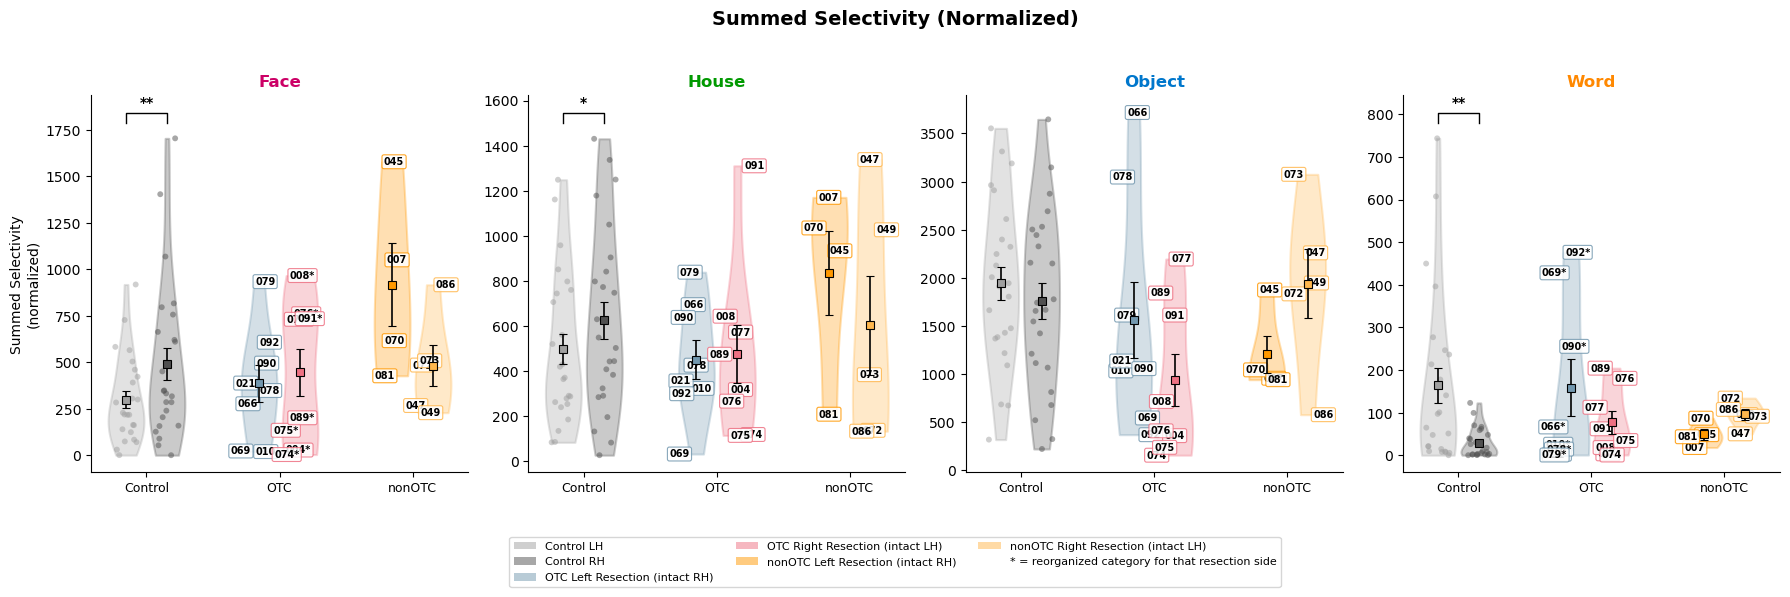

Saved: fig_selectivity_sum_selec_norm.png


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7: Figure — Summed Selectivity
# ═══════════════════════════════════════════════════════════════════════════════

n_cats = len(CATEGORIES)
fig, axes = plt.subplots(1, n_cats, figsize=(4.5 * n_cats, 5.5), sharey=False)

for col_idx, cat in enumerate(CATEGORIES):
    ax = axes[col_idx]
    vd, vp, vc = [], [], []

    # ── Controls L/R ──────────────────────────────────────────────────────
    cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'left')][METRIC].values
    cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'right')][METRIC].values

    for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
        if len(vals) < 2:
            continue
        vd.append(vals); vp.append(pos); vc.append(color)
        jit = RNG.uniform(-0.12, 0.12, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
        ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=color, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── OTC Left/Right resection ──────────────────────────────────────────
    for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
        sd   = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(color)
        for _, row in sd.iterrows():
            jit  = RNG.uniform(-0.18, 0.18)
            lbl  = short_name(row['sub'])
            star = '*' if REORG.get(side) == cat else ''
            ax.annotate(f'{lbl}{star}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=color, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── nonOTC Left/Right resection ───────────────────────────────────────
    for side, pos, fc in [('left', 2.6, NONOT), ('right', 3.0, '#FFB74D')]:
        sd = nonotc[(nonotc['category'] == cat) & (nonotc['surgery_side'] == side)]
        vals = sd[METRIC].values
        if len(vals) >= 2:
            vd.append(vals); vp.append(pos); vc.append(fc)
        for _, row in sd.iterrows():
            jit = RNG.uniform(-0.18, 0.18)
            lbl = short_name(row['sub'])
            ax.annotate(f'{lbl}', (pos + jit, row[METRIC]),
                        fontsize=7, fontweight='bold', ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                  edgecolor=fc, alpha=0.85, linewidth=0.8),
                        zorder=4)
        if len(vals) > 0:
            ax.errorbar(pos, np.mean(vals),
                        yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=fc, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

    # ── Violins ───────────────────────────────────────────────────────────
    if vd:
        vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                              showmedians=False, showextrema=False, widths=0.35)
        for i, body in enumerate(vplot['bodies']):
            body.set_facecolor(vc[i]); body.set_alpha(0.3)
            body.set_edgecolor(vc[i]); body.set_linewidth(1.5)

    # ── Lateralization bracket (controls) ─────────────────────────────────
    if cat in lat_results and lat_results[cat]['sig']:
        y_max = max(cl.max() if len(cl) > 0 else 0,
                    cr.max() if len(cr) > 0 else 0)
        bracket_y = y_max * 1.05
        ax.plot([0.0, 0.0, 0.4, 0.4],
                [bracket_y, bracket_y * 1.03, bracket_y * 1.03, bracket_y],
                color='black', linewidth=1, clip_on=False)
        p = lat_results[cat]['p']
        sig_str = '***' if p < 0.001 else '**' if p < 0.01 else '*'
        ax.text(0.2, bracket_y * 1.04, sig_str,
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks([0.2, 1.5, 2.8])
    ax.set_xticklabels(['Control', 'OTC', 'nonOTC'], fontsize=9)
    ax.set_title(cat.title(), fontsize=12, fontweight='bold',
                 color=CAT_COLORS[cat])
    if col_idx == 0:
        ax.set_ylabel('Summed Selectivity\n(normalized)')

# ── Legend ─────────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=CTRL_L, alpha=0.5, label='Control LH'),
    Patch(facecolor=CTRL_R, alpha=0.5, label='Control RH'),
    Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection (intact RH)'),
    Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection (intact LH)'),
    Patch(facecolor=NONOT,  alpha=0.5, label='nonOTC Left Resection (intact RH)'),
    Patch(facecolor='#FFB74D', alpha=0.5, label='nonOTC Right Resection (intact LH)'),
    Line2D([0], [0], marker='None', color='none',
           label='* = reorganized category for that resection side'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Summed Selectivity (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(str(FIG_DIR / f'fig_selectivity_{METRIC}.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: fig_selectivity_{METRIC}.png')

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8: Longitudinal T1→T2 Summed Selectivity (Controls + OTC only)
#
# Controls: paired T1 vs T2, bootstrap change distribution
# OTC: individual patient T1→T2 change vs bootstrapped control change
# Hemisphere-matched: same hemisphere tracked across sessions
# ═══════════════════════════════════════════════════════════════════════════════

EXCLUDE = ['sub-017']
N_ITER = 10000
N_SUBS_BOOT = 4

# ── Reload without first-session filter ───────────────────────────────────
df_long = pd.read_csv(sel_file)
df_long = df_long[~df_long['sub'].isin(EXCLUDE)]
df_long['ses_int'] = df_long['ses'].astype(int)

# Identify subjects with 2+ sessions
ses_counts = df_long.groupby('sub')['ses_int'].nunique()
multi_subs = ses_counts[ses_counts >= 2].index.tolist()

# Get first two sessions per subject
df_long = df_long[df_long['sub'].isin(multi_subs)]
ranked = df_long.groupby('sub')['ses_int'].rank(method='dense').astype(int)
df_long['ses_rank'] = ranked
df_long = df_long[df_long['ses_rank'] <= 2]
df_long['timepoint'] = df_long['ses_rank'].map({1: 'T1', 2: 'T2'})

ctrl_long = df_long[df_long['group'] == 'control'].copy()
otc_long  = df_long[df_long['group'] == 'OTC'].copy()

print(f'Longitudinal controls: {ctrl_long["sub"].nunique()} subjects')
print(f'Longitudinal OTC:      {otc_long["sub"].nunique()} subjects')
print(f'  OTC subs: {sorted(otc_long["sub"].unique())}')

# ══════════════════════════════════════════════════════════════════════════════
# 8a. CONTROLS: Paired T1 vs T2
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('8a. CONTROLS: Paired T1 vs T2 per category × hemisphere')
print('='*70)

ctrl_change = {}  # store change scores for bootstrapping

for cat in CATEGORIES:
    for hemi in ['left', 'right']:
        t1 = ctrl_long[(ctrl_long['category'] == cat) & 
                        (ctrl_long['hemi'] == hemi) & 
                        (ctrl_long['timepoint'] == 'T1')][['sub', METRIC]].set_index('sub')
        t2 = ctrl_long[(ctrl_long['category'] == cat) & 
                        (ctrl_long['hemi'] == hemi) & 
                        (ctrl_long['timepoint'] == 'T2')][['sub', METRIC]].set_index('sub')
        
        paired = t1.join(t2, lsuffix='_t1', rsuffix='_t2').dropna()
        if len(paired) < 3:
            print(f'  {cat} {hemi}: n={len(paired)} — too few')
            continue
        
        change = paired[f'{METRIC}_t2'] - paired[f'{METRIC}_t1']
        ctrl_change[f'{cat}_{hemi}'] = change.values
        
        t_stat, t_p = ttest_rel(paired[f'{METRIC}_t1'].values, 
                                 paired[f'{METRIC}_t2'].values)
        d = change.mean() / change.std() if change.std() > 0 else np.nan
        
        print(f'\n  {cat} {hemi}: n={len(paired)}')
        print(f'    T1: M={paired[f"{METRIC}_t1"].mean():.1f} (SD={paired[f"{METRIC}_t1"].std():.1f})')
        print(f'    T2: M={paired[f"{METRIC}_t2"].mean():.1f} (SD={paired[f"{METRIC}_t2"].std():.1f})')
        print(f'    Change: M={change.mean():.1f} (SD={change.std():.1f})')
        print(f'    t({len(paired)-1})={t_stat:.3f}, p={t_p:.4f}, d={d:.3f}')

# ══════════════════════════════════════════════════════════════════════════════
# 8b. BOOTSTRAP CONTROL CHANGE DISTRIBUTION
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('8b. Bootstrapping control T1→T2 change distributions')
print('='*70)

rng = np.random.default_rng(42)
boot_change = {}

for key, changes in ctrl_change.items():
    n_avail = len(changes)
    n_draw = min(N_SUBS_BOOT, n_avail)
    idx = rng.choice(n_avail, size=(N_ITER, n_draw), replace=True)
    boot_change[key] = changes[idx].mean(axis=1)
    ci_lo = np.percentile(boot_change[key], 2.5)
    ci_hi = np.percentile(boot_change[key], 97.5)
    print(f'  {key}: n={n_avail}, boot CI=[{ci_lo:.1f}, {ci_hi:.1f}]')

# ══════════════════════════════════════════════════════════════════════════════
# 8c. OTC PATIENTS: Individual T1→T2 vs bootstrapped control change
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('8c. OTC PATIENTS: Individual T1→T2 change vs control distribution')
print('    Hemisphere-matched (patient intact hemi vs same control hemi)')
print('='*70)

long_rows = []

for sub in sorted(otc_long['sub'].unique()):
    sub_data = otc_long[otc_long['sub'] == sub]
    intact = sub_data['intact_hemi'].iloc[0]
    
    print(f'\n  {sub} (intact {intact}):')
    
    for cat in CATEGORIES:
        t1_row = sub_data[(sub_data['category'] == cat) & 
                          (sub_data['timepoint'] == 'T1')]
        t2_row = sub_data[(sub_data['category'] == cat) & 
                          (sub_data['timepoint'] == 'T2')]
        
        if t1_row.empty or t2_row.empty:
            print(f'    {cat}: missing timepoint')
            continue
        
        t1_val = t1_row[METRIC].values[0]
        t2_val = t2_row[METRIC].values[0]
        pt_change = t2_val - t1_val
        
        # Compare against same-hemisphere control change distribution
        boot_key = f'{cat}_{intact}'
        if boot_key not in boot_change:
            print(f'    {cat}: no control change distribution for {intact}')
            continue
        
        boot_dist = boot_change[boot_key]
        pctile = float(np.mean(boot_dist <= pt_change) * 100)
        ci_lo = np.percentile(boot_dist, 2.5)
        ci_hi = np.percentile(boot_dist, 97.5)
        
        # Flag if change is outside control CI (either direction)
        abnormal_decrease = pt_change < ci_lo
        abnormal_increase = pt_change > ci_hi
        
        if abnormal_decrease:
            flag = '↓↓ ABNORMAL DECREASE'
        elif abnormal_increase:
            flag = '↑↑ ABNORMAL INCREASE'
        else:
            flag = 'within control range'
        
        pref = PREFERRED_HEMI[cat]
        is_reorg = (intact != pref)
        test_type = 'reorg' if is_reorg else 'normal'
        
        print(f'    {cat} [{test_type}]: T1={t1_val:.0f}, T2={t2_val:.0f}, '
              f'Δ={pt_change:+.0f} ({pctile:.0f}%) → {flag}')
        
        long_rows.append({
            'sub': sub, 'intact_hemi': intact, 'category': cat,
            'test_type': test_type,
            't1': t1_val, 't2': t2_val, 'change': pt_change,
            'pctile': pctile, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
            'abnormal_decrease': abnormal_decrease,
            'abnormal_increase': abnormal_increase,
        })

df_longitudinal = pd.DataFrame(long_rows)

# ── Summary ───────────────────────────────────────────────────────────────
if len(df_longitudinal) > 0:
    print('\n' + '='*70)
    print('SUMMARY: OTC T1→T2 change')
    print('='*70)
    for test_type in ['reorg', 'normal']:
        grp = df_longitudinal[df_longitudinal['test_type'] == test_type]
        print(f'\n  {test_type} categories:')
        print(f'  {"category":<10} {"n":>3} {"mean_Δ":>8} {"abn_dec":>8} {"abn_inc":>8} {"stable":>7}')
        for cat in CATEGORIES:
            c = grp[grp['category'] == cat]
            n = len(c)
            if n == 0:
                continue
            mean_change = c['change'].mean()
            n_dec = int(c['abnormal_decrease'].sum())
            n_inc = int(c['abnormal_increase'].sum())
            n_stable = n - n_dec - n_inc
            print(f'  {cat:<10} {n:>3} {mean_change:>+8.0f} {n_dec:>5}/{n:<2} {n_inc:>5}/{n:<2} {n_stable:>4}/{n}')

Longitudinal controls: 9 subjects
Longitudinal OTC:      5 subjects
  OTC subs: ['sub-004', 'sub-008', 'sub-010', 'sub-021', 'sub-079']

8a. CONTROLS: Paired T1 vs T2 per category × hemisphere

  face left: n=9
    T1: M=280.4 (SD=163.3)
    T2: M=331.0 (SD=211.9)
    Change: M=50.7 (SD=144.3)
    t(8)=-1.053, p=0.3229, d=0.351

  face right: n=9
    T1: M=352.2 (SD=236.7)
    T2: M=473.8 (SD=236.5)
    Change: M=121.6 (SD=189.6)
    t(8)=-1.924, p=0.0905, d=0.641

  house left: n=9
    T1: M=635.0 (SD=320.8)
    T2: M=872.6 (SD=430.1)
    Change: M=237.6 (SD=353.0)
    t(8)=-2.020, p=0.0781, d=0.673

  house right: n=9
    T1: M=706.2 (SD=432.3)
    T2: M=943.1 (SD=428.5)
    Change: M=236.9 (SD=353.3)
    t(8)=-2.012, p=0.0790, d=0.671

  object left: n=9
    T1: M=1699.1 (SD=803.7)
    T2: M=1555.7 (SD=771.0)
    Change: M=-143.4 (SD=1260.3)
    t(8)=0.341, p=0.7417, d=-0.114

  object right: n=9
    T1: M=1443.6 (SD=875.6)
    T2: M=1190.2 (SD=703.1)
    Change: M=-253.5 (SD=1235.2

LONGITUDINAL SUMMED SELECTIVITY CHANGE (T2 - T1)

Controls:
  face left: ΔM=50.7 (SD=136.0), t(8)=-1.053, p=0.3229
  face right: ΔM=121.6 (SD=178.7), t(8)=-1.924, p=0.0905
  house left: ΔM=237.6 (SD=332.8), t(8)=-2.020, p=0.0781
  house right: ΔM=236.9 (SD=333.1), t(8)=-2.012, p=0.0790
  object left: ΔM=-143.4 (SD=1188.2), t(8)=0.341, p=0.7417
  object right: ΔM=-253.5 (SD=1164.5), t(8)=0.616, p=0.5553
  word left: ΔM=27.4 (SD=158.2), t(8)=-0.491, p=0.6368
  word right: ΔM=7.7 (SD=32.9), t(8)=-0.663, p=0.5260

OTC patients:
  sub-004 face [reorg]: Δ=+183, CI=[-89,180] **ABNORMAL**
  sub-004 house [reorg]: Δ=+19, CI=[-89,573] 
  sub-004 object [normal]: Δ=+396, CI=[-1180,1062] 
  sub-004 word [normal]: Δ=+146, CI=[-124,186] 
  sub-008 face [reorg]: Δ=-831, CI=[-89,180] **ABNORMAL**
  sub-008 house [reorg]: Δ=-556, CI=[-89,573] **ABNORMAL**
  sub-008 object [normal]: Δ=-696, CI=[-1180,1062] 
  sub-008 word [normal]: Δ=-2, CI=[-124,186] 
  sub-010 face [normal]: Δ=-2, CI=[-27,308] 
  sub-

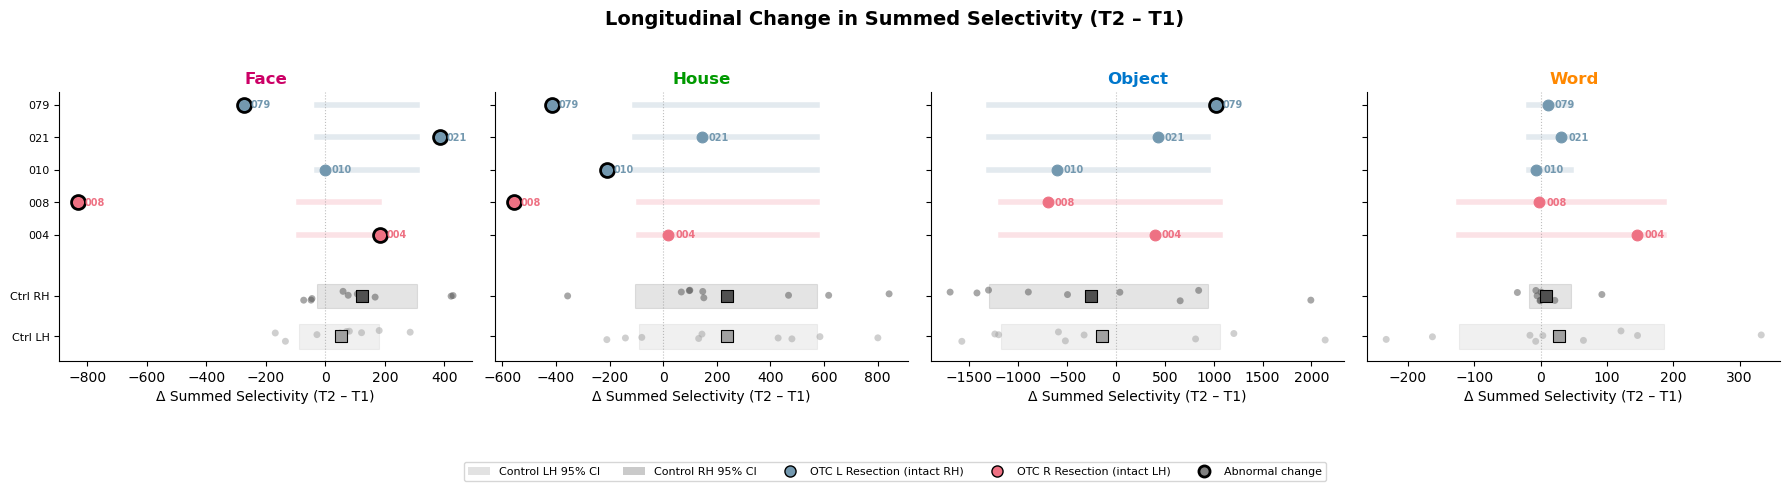

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8c: Longitudinal T1→T2 — Summed Selectivity Change Scores
# ═══════════════════════════════════════════════════════════════════════════════

METRIC_LONG = 'sum_selec_norm'
N_ITER = 10000
N_SUBS_BOOT = 4
rng = np.random.default_rng(42)

# ── Compute control change scores ─────────────────────────────────────────
ctrl_change_ss = {}
ctrl_change_details_ss = {}

for cat in CATEGORIES:
    for hemi in ['left', 'right']:
        t1 = ctrl_long[(ctrl_long['category'] == cat) &
                        (ctrl_long['hemi'] == hemi) &
                        (ctrl_long['timepoint'] == 'T1')][['sub', METRIC_LONG]].set_index('sub')
        t2 = ctrl_long[(ctrl_long['category'] == cat) &
                        (ctrl_long['hemi'] == hemi) &
                        (ctrl_long['timepoint'] == 'T2')][['sub', METRIC_LONG]].set_index('sub')
        paired = t1.join(t2, lsuffix='_t1', rsuffix='_t2').dropna()
        if len(paired) < 3:
            continue
        change = (paired[f'{METRIC_LONG}_t2'] - paired[f'{METRIC_LONG}_t1']).values
        ctrl_change_ss[f'{cat}_{hemi}'] = change
        ctrl_change_details_ss[f'{cat}_{hemi}'] = paired

# ── Bootstrap control change distributions ────────────────────────────────
boot_change_ss = {}
for key, changes in ctrl_change_ss.items():
    n_avail = len(changes)
    n_draw = min(N_SUBS_BOOT, n_avail)
    idx = rng.choice(n_avail, size=(N_ITER, n_draw), replace=True)
    boot_change_ss[key] = changes[idx].mean(axis=1)

# ── Compute OTC patient change scores ─────────────────────────────────────
pt_change_rows_ss = []
for sub in sorted(otc_long['sub'].unique()):
    sub_data = otc_long[otc_long['sub'] == sub]
    intact = sub_data['intact_hemi'].iloc[0]
    surgery_side = 'right' if intact == 'left' else 'left'

    for cat in CATEGORIES:
        t1_row = sub_data[(sub_data['category'] == cat) & (sub_data['timepoint'] == 'T1')]
        t2_row = sub_data[(sub_data['category'] == cat) & (sub_data['timepoint'] == 'T2')]
        if t1_row.empty or t2_row.empty:
            continue

        t1_val = t1_row[METRIC_LONG].values[0]
        t2_val = t2_row[METRIC_LONG].values[0]
        pt_ch = t2_val - t1_val

        boot_key = f'{cat}_{intact}'
        ci_lo = np.percentile(boot_change_ss[boot_key], 2.5) if boot_key in boot_change_ss else np.nan
        ci_hi = np.percentile(boot_change_ss[boot_key], 97.5) if boot_key in boot_change_ss else np.nan

        pref = PREFERRED_HEMI[cat]
        is_reorg = (intact != pref)

        pt_change_rows_ss.append({
            'sub': sub, 'intact_hemi': intact, 'surgery_side': surgery_side,
            'category': cat, 'change': pt_ch,
            'test_type': 'reorg' if is_reorg else 'normal',
            'ci_lo': ci_lo, 'ci_hi': ci_hi,
            'abnormal': pt_ch < ci_lo or pt_ch > ci_hi,
        })

df_pt_change_ss = pd.DataFrame(pt_change_rows_ss)

# ── Print stats ───────────────────────────────────────────────────────────
print('='*70)
print(f'LONGITUDINAL SUMMED SELECTIVITY CHANGE (T2 - T1)')
print('='*70)

print('\nControls:')
for cat in CATEGORIES:
    for hemi in ['left', 'right']:
        key = f'{cat}_{hemi}'
        if key not in ctrl_change_ss:
            continue
        ch = ctrl_change_ss[key]
        t_stat, t_p = ttest_rel(
            ctrl_change_details_ss[key][f'{METRIC_LONG}_t1'].values,
            ctrl_change_details_ss[key][f'{METRIC_LONG}_t2'].values
        )
        print(f'  {cat} {hemi}: ΔM={ch.mean():.1f} (SD={ch.std():.1f}), '
              f't({len(ch)-1})={t_stat:.3f}, p={t_p:.4f}')

print('\nOTC patients:')
for _, r in df_pt_change_ss.iterrows():
    flag = '**ABNORMAL**' if r['abnormal'] else ''
    print(f'  {r["sub"]} {r["category"]} [{r["test_type"]}]: '
          f'Δ={r["change"]:+.0f}, CI=[{r["ci_lo"]:.0f},{r["ci_hi"]:.0f}] {flag}')

# ── Figure: Change score dot plot ─────────────────────────────────────────
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(4.5 * len(CATEGORIES), 4.5),
                          sharey=True)

for col_idx, cat in enumerate(CATEGORIES):
    ax = axes[col_idx]

    for hemi, color, y_base in [('left', CTRL_L, 0), ('right', CTRL_R, 1)]:
        key = f'{cat}_{hemi}'
        if key not in ctrl_change_ss:
            continue

        changes = ctrl_change_ss[key]
        ci_lo = np.percentile(boot_change_ss[key], 2.5)
        ci_hi = np.percentile(boot_change_ss[key], 97.5)

        ax.barh(y_base, ci_hi - ci_lo, left=ci_lo, height=0.6,
                color=color, alpha=0.15, edgecolor=color, linewidth=0.8)
        jit = RNG.uniform(-0.15, 0.15, len(changes))
        ax.scatter(changes, np.full(len(changes), y_base) + jit,
                   color=color, alpha=0.5, s=25, zorder=3, edgecolors='none')
        ax.scatter(changes.mean(), y_base, color=color, s=80, marker='s',
                   edgecolors='black', linewidth=0.8, zorder=5)

    pt_cat = df_pt_change_ss[df_pt_change_ss['category'] == cat]
    for i, (_, r) in enumerate(pt_cat.iterrows()):
        y_pos = 2.5 + i * 0.8
        pt_color = OTC_L if r['surgery_side'] == 'left' else OTC_R

        marker_size = 100 if r['abnormal'] else 60
        edge = 'black' if r['abnormal'] else pt_color
        edge_w = 2.0 if r['abnormal'] else 0.8

        ax.scatter(r['change'], y_pos, color=pt_color, s=marker_size,
                   edgecolors=edge, linewidth=edge_w, zorder=5)
        ax.annotate(short_name(r['sub']),
                    (r['change'], y_pos), fontsize=7, fontweight='bold',
                    xytext=(5, 0), textcoords='offset points',
                    va='center', color=pt_color, zorder=6)

        boot_key = f'{cat}_{r["intact_hemi"]}'
        if boot_key in boot_change_ss:
            ci_lo = np.percentile(boot_change_ss[boot_key], 2.5)
            ci_hi = np.percentile(boot_change_ss[boot_key], 97.5)
            ax.plot([ci_lo, ci_hi], [y_pos, y_pos],
                    color=pt_color, alpha=0.2, linewidth=4, zorder=1)

    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.set_title(cat.title(), fontsize=12, fontweight='bold', color=CAT_COLORS[cat])
    if col_idx == 0:
        ax.set_ylabel('')
    ax.set_xlabel('Δ Summed Selectivity (T2 – T1)')

    yticks = [0, 1] + [2.5 + i * 0.8 for i in range(len(pt_cat))]
    ylabels = ['Ctrl LH', 'Ctrl RH'] + [short_name(r['sub']) for _, r in pt_cat.iterrows()]
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8)

legend_elements = [
    Patch(facecolor=CTRL_L, alpha=0.3, label='Control LH 95% CI'),
    Patch(facecolor=CTRL_R, alpha=0.3, label='Control RH 95% CI'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=OTC_L,
           markersize=8, label='OTC L Resection (intact RH)'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=OTC_R,
           markersize=8, label='OTC R Resection (intact LH)'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='gray',
           markeredgecolor='black', markeredgewidth=2, markersize=8,
           label='Abnormal change'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=5, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Longitudinal Change in Summed Selectivity (T2 – T1)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig(str(FIG_DIR / f'fig_longitudinal_change_sum_selec_norm.png'),
            dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Summary table for paper
print('='*70)
print('LONGITUDINAL SUMMED SELECTIVITY: Patient change vs control 95% CI')
print('Abnormal = outside bootstrapped 95% CI of control change distribution')
print('='*70)

for _, r in df_pt_change_ss.sort_values(['sub', 'category']).iterrows():
    flag = '**' if r['abnormal'] else '  '
    direction = '↓' if r['change'] < 0 else '↑'
    print(f'{flag} {r["sub"]} {r["category"]:<8} [{r["test_type"]:<6}]: '
          f'Δ={r["change"]:>+8.0f}  CI=[{r["ci_lo"]:>+8.0f}, {r["ci_hi"]:>+8.0f}] {direction}')

LONGITUDINAL SUMMED SELECTIVITY: Patient change vs control 95% CI
Abnormal = outside bootstrapped 95% CI of control change distribution
** sub-004 face     [reorg ]: Δ=    +183  CI=[     -89,     +180] ↑
   sub-004 house    [reorg ]: Δ=     +19  CI=[     -89,     +573] ↑
   sub-004 object   [normal]: Δ=    +396  CI=[   -1180,    +1062] ↑
   sub-004 word     [normal]: Δ=    +146  CI=[    -124,     +186] ↑
** sub-008 face     [reorg ]: Δ=    -831  CI=[     -89,     +180] ↓
** sub-008 house    [reorg ]: Δ=    -556  CI=[     -89,     +573] ↓
   sub-008 object   [normal]: Δ=    -696  CI=[   -1180,    +1062] ↓
   sub-008 word     [normal]: Δ=      -2  CI=[    -124,     +186] ↓
   sub-010 face     [normal]: Δ=      -2  CI=[     -27,     +308] ↓
** sub-010 house    [normal]: Δ=    -210  CI=[    -104,     +575] ↓
   sub-010 object   [reorg ]: Δ=    -605  CI=[   -1299,     +937] ↓
   sub-010 word     [reorg ]: Δ=      -7  CI=[     -18,      +46] ↓
** sub-021 face     [normal]: Δ=    +384  CI=[  

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8d: Longitudinal Summary Table — Change Magnitudes + CI Context
# ═══════════════════════════════════════════════════════════════════════════════

# ── Interpretive note ─────────────────────────────────────────────────────
print('='*70)
print('NOTE ON INTERPRETING LONGITUDINAL CHANGE')
print('='*70)
print('''
Face and house show the most T1→T2 change relative to expected control 
variability (4/5 and 3/5 patients abnormal, respectively). However, this 
is partly driven by control CI width: controls are very stable for face 
and house, so even moderate patient changes are flagged as abnormal. 
Object has wide control CIs (~±1200), so equivalent absolute changes in 
patients do not register as abnormal.

The more precise statement: face and house show the most change RELATIVE 
TO expected control variability. This is consistent with the crowding 
hypothesis — house (bilateral, supposedly stable per Liu) is the second 
most unstable category longitudinally, with all abnormal cases being 
decreases, suggesting degradation from competitive pressure over time.
''')

# ── Table: Raw change + CI context per category ──────────────────────────
rows = []
for cat in CATEGORIES:
    pt_cat = df_pt_change_ss[df_pt_change_ss['category'] == cat]
    
    # Patient absolute change
    abs_changes = pt_cat['change'].abs()
    mean_abs = abs_changes.mean()
    max_abs = abs_changes.max()
    
    # Mean direction
    mean_change = pt_cat['change'].mean()
    
    # Control CI width (average across hemispheres)
    ci_widths = []
    for hemi in ['left', 'right']:
        key = f'{cat}_{hemi}'
        if key in boot_change_ss:
            ci_lo = np.percentile(boot_change_ss[key], 2.5)
            ci_hi = np.percentile(boot_change_ss[key], 97.5)
            ci_widths.append(ci_hi - ci_lo)
    mean_ci_width = np.mean(ci_widths) if ci_widths else np.nan
    
    # Abnormal count
    n_abnormal = int(pt_cat['abnormal'].sum())
    n_total = len(pt_cat)
    
    # Direction of abnormal changes
    n_abn_dec = int(((pt_cat['change'] < pt_cat['ci_lo']) & pt_cat['abnormal']).sum())
    n_abn_inc = int(((pt_cat['change'] > pt_cat['ci_hi']) & pt_cat['abnormal']).sum())
    
    rows.append({
        'category': cat,
        'mean_Δ': mean_change,
        'mean_|Δ|': mean_abs,
        'max_|Δ|': max_abs,
        'ctrl_CI_width': mean_ci_width,
        'ratio_|Δ|/CI': mean_abs / mean_ci_width if mean_ci_width > 0 else np.nan,
        'n_abnormal': f'{n_abnormal}/{n_total}',
        'direction': f'{n_abn_dec}↓ {n_abn_inc}↑',
    })

df_table = pd.DataFrame(rows)

print('='*70)
print('LONGITUDINAL CHANGE: Raw Magnitude + Control CI Context')
print('='*70)
print(f'{"Category":<10} {"Mean Δ":>8} {"Mean |Δ|":>9} {"Max |Δ|":>9} '
      f'{"Ctrl CI":>9} {"|Δ|/CI":>7} {"Abnormal":>9} {"Direction":>10}')
print('-'*70)
for _, r in df_table.iterrows():
    print(f'{r["category"]:<10} {r["mean_Δ"]:>+8.0f} {r["mean_|Δ|"]:>9.0f} {r["max_|Δ|"]:>9.0f} '
          f'{r["ctrl_CI_width"]:>9.0f} {r["ratio_|Δ|/CI"]:>7.2f} {r["n_abnormal"]:>9} {r["direction"]:>10}')

print(f'\n  |Δ|/CI ratio: patient mean absolute change relative to control CI width')
print(f'  Values > 1.0 = patients changing more than the full control CI width')
print(f'  Higher ratio = more abnormal change relative to expected variability')

NOTE ON INTERPRETING LONGITUDINAL CHANGE

Face and house show the most T1→T2 change relative to expected control 
variability (4/5 and 3/5 patients abnormal, respectively). However, this 
is partly driven by control CI width: controls are very stable for face 
and house, so even moderate patient changes are flagged as abnormal. 
Object has wide control CIs (~±1200), so equivalent absolute changes in 
patients do not register as abnormal.

The more precise statement: face and house show the most change RELATIVE 
TO expected control variability. This is consistent with the crowding 
hypothesis — house (bilateral, supposedly stable per Liu) is the second 
most unstable category longitudinally, with all abnormal cases being 
decreases, suggesting degradation from competitive pressure over time.

LONGITUDINAL CHANGE: Raw Magnitude + Control CI Context
Category     Mean Δ  Mean |Δ|   Max |Δ|   Ctrl CI  |Δ|/CI  Abnormal  Direction
--------------------------------------------------------------